In [5]:
"""
rustyecon — supply chain sim

Manchester: MagicProducer(wheat) → grain mill → flour → pops.
UBI=10 GBP/tick. savings_target=0.75.

Set PLOTS = True to render figures (or copy to a .ipynb to see them inline).
"""

import sys
from pathlib import Path

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "Cargo.toml").exists())
sys.path.insert(0, str(_root / "tools"))

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scenario import run_simulation, load_scenario
from readers import load_scenario_results, ScenarioResults

# ── settings ──────────────────────────────────────────────────────────────────
PLOTS    = True
SCENARIO = "multi_region"
TICKS    = 1000
OUTPUT   = _root / "tmp" / SCENARIO

NODE = 0
# ─────────────────────────────────────────────────────────────────────────────


def load() -> ScenarioResults:
    gd = load_scenario(SCENARIO)
    return load_scenario_results(OUTPUT, gd)


def print_stats(res: ScenarioResults) -> None:
    wheat_p   = res.prices_for("wheat", node_id=NODE)
    flour_p   = res.prices_for("flour", node_id=NODE)
    wheat_imb = res.volume_for("wheat", "imbalance", node_id=NODE)
    flour_imb = res.volume_for("flour", "imbalance", node_id=NODE)
    pop_gbp   = res.inventory_for("pop", 0, "GBP")
    pi        = res.price_index()
    yoy       = res.yoy_inflation()
    bal       = res.building_series(0, "balance") if not res.buildings.empty else None

    print("=== prices, GBP & inflation (selected ticks) ===")
    print(
        f"{'tick':>5}  {'wheat p':>8}  {'flour p':>8}"
        f"  {'wheat imb':>10}  {'flour imb':>10}"
        f"  {'pop GBP':>9}  {'price idx':>10}  {'yoy %':>7}"
    )
    nan = float("nan")
    ticks_to_show = list(range(1, 20)) + [49, 50, 51, 52, 55, 60, 70, 100, TICKS]
    for t in ticks_to_show:
        if t not in wheat_p.index:
            continue
        print(
            f"{t:>5}  {wheat_p.get(t, nan):>8.4f}  {flour_p.get(t, nan):>8.4f}"
            f"  {wheat_imb.get(t, nan):>10.4f}  {flour_imb.get(t, nan):>10.4f}"
            f"  {pop_gbp.get(t, nan):>9.2f}"
            f"  {pi.get(t, nan):>10.4f}  {yoy.get(t, nan):>7.2f}"
        )

    if not pi.empty:
        print(f"\nprice index range: [{pi.min():.4f}, {pi.max():.4f}]")
        print(f"peak price index:  {pi.max():.4f} at tick {pi.idxmax()}")

    if bal is not None and not bal.empty:
        print("\n=== mill (building 0) P&L balance (selected ticks) ===")
        print(f"{'tick':>5}  {'balance':>12}")
        for t in ticks_to_show:
            if t in bal.index:
                print(f"{t:>5}  {bal.loc[t]:>12.4f}")
        print(f"\nbalance range: [{bal.min():.4f}, {bal.max():.4f}]")
    else:
        print("\n(no buildings data — run with --human-save 1)")

    avg_wealth = res.pop_wealth_by_region()
    if not avg_wealth.empty:
        print("\n=== average pop wealth (selected ticks) ===")
        print(f"{'tick':>5}  {'avg wealth':>12}")
        for t in ticks_to_show:
            if t in avg_wealth.index:
                print(f"{t:>5}  {avg_wealth.loc[t]:>12.4f}")
        print(f"\nwealth range: [{avg_wealth.min():.4f}, {avg_wealth.max():.4f}]")

    last = res.inventories["tick"].max() if not res.inventories.empty else None
    if last is not None:
        print(f"\n=== building inventories at tick {last} ===")
        snap = res.inventories[
            (res.inventories["entity_type"] == "building") &
            (res.inventories["tick"] == last)
        ]
        for _, row in snap.iterrows():
            name = res.good_name.get(int(row["good_id"]), f"good{int(row['good_id'])}")
            print(f"  bld {int(row['entity_id'])}  {name:>5}: {row['qty']:.2f}")


def plot(res: ScenarioResults) -> None:
    wheat_p   = res.prices_for("wheat", node_id=NODE).reset_index()
    flour_p   = res.prices_for("flour", node_id=NODE).reset_index()
    wheat_imb = res.volume_for("wheat", "imbalance", node_id=NODE).reset_index()
    flour_imb = res.volume_for("flour", "imbalance", node_id=NODE).reset_index()
    wheat_s   = res.volume_for("wheat", "supply",    node_id=NODE).reset_index()
    wheat_d   = res.volume_for("wheat", "demand",    node_id=NODE).reset_index()
    flour_s   = res.volume_for("flour", "supply",    node_id=NODE).reset_index()
    flour_d   = res.volume_for("flour", "demand",    node_id=NODE).reset_index()
    pop_gbp   = res.inventory_for("pop", 0, "GBP").reset_index()
    bld_gbp   = res.inventory_for("building", 0, "GBP").reset_index()
    mill_flour= res.inventory_for("building", 0, "flour").reset_index()
    bal_df    = (res.buildings[res.buildings["building_id"] == 0][["tick", "balance"]]
                 if not res.buildings.empty else None)
    pi        = res.price_index().reset_index()
    pi.columns = ["tick", "price_index"]
    yoy       = res.yoy_inflation().dropna().reset_index()
    yoy.columns = ["tick", "yoy_inflation_pct"]
    avg_wealth = res.pop_wealth_by_region().reset_index()
    avg_wealth.columns = ["tick", "wealth"]

    fig = plt.figure(figsize=(14, 18))
    fig.suptitle("Supply chain: wheat → mill → flour → pops", fontsize=13)
    gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.35)

    # Row 0: prices
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(wheat_p["tick"], wheat_p["price"], label="wheat", lw=1.5)
    ax1.plot(flour_p["tick"], flour_p["price"], label="flour", lw=1.5, ls="--")
    ax1.set_title("Prices")
    ax1.set_xlabel("tick")
    ax1.legend()

    # Row 1 left: imbalance + supply/demand volumes
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(wheat_imb["tick"], wheat_imb["imbalance"], label="wheat imb", lw=0.8, alpha=0.2)
    ax2.plot(flour_imb["tick"], flour_imb["imbalance"], label="flour imb", lw=0.8, alpha=0.2)
    ax2.set_title("Imbalance & market volumes")
    ax2.set_xlabel("tick")
    ax2.set_ylabel("imbalance", fontsize=8)
    if not wheat_s.empty:
        ax2r = ax2.twinx()
        ax2r.plot(wheat_s["tick"], wheat_s["supply"],  color="tab:blue",   lw=1.1, alpha=0.8, ls="-",  label="wheat sell")
        ax2r.plot(wheat_d["tick"], wheat_d["demand"],  color="tab:blue",   lw=1.1, alpha=0.8, ls=":",  label="wheat buy")
        ax2r.plot(flour_s["tick"], flour_s["supply"],  color="tab:orange", lw=1.1, alpha=0.8, ls="-",  label="flour sell")
        ax2r.plot(flour_d["tick"], flour_d["demand"],  color="tab:orange", lw=1.1, alpha=0.8, ls=":",  label="flour buy")
        ax2r.set_ylabel("volume", fontsize=8)
        ax2r.legend(loc="upper right", fontsize=7, ncol=2)
    ax2.legend(loc="upper left", fontsize=8)

    # Row 1 right: GBP cash inventory
    ax3 = fig.add_subplot(gs[1, 1])
    if not pop_gbp.empty:
        ax3.plot(pop_gbp["tick"], pop_gbp["qty"], lw=1.5, color="tab:green",  label="pop GBP (inv)")
    if not bld_gbp.empty:
        ax3.plot(bld_gbp["tick"], bld_gbp["qty"], lw=1.5, color="tab:orange", ls="--", label="mill GBP (inv)")
    ax3.set_title("GBP cash (inventory)")
    ax3.set_xlabel("tick")
    ax3.legend(fontsize=8)

    # Row 2 left: mill flour inventory
    ax4 = fig.add_subplot(gs[2, 0])
    if not mill_flour.empty:
        ax4.plot(mill_flour["tick"], mill_flour["qty"], lw=1.5, label="mill flour stock")
    ax4.set_title("Mill flour inventory")
    ax4.set_xlabel("tick")
    ax4.legend(fontsize=8)

    # Row 2 right: mill P&L balance
    ax5 = fig.add_subplot(gs[2, 1])
    if bal_df is not None and not bal_df.empty:
        ax5.axhline(0, color="k", lw=0.5, ls="--")
        ax5.plot(bal_df["tick"], bal_df["balance"], lw=1.5, color="tab:purple", label="mill balance")
        ax5.legend(fontsize=8)
    else:
        ax5.text(0.5, 0.5, "no RON data\n(run with --human-save 1)", ha="center", va="center",
                 transform=ax5.transAxes, fontsize=9, color="grey")
    ax5.set_title("Mill P&L balance (ledger)")
    ax5.set_xlabel("tick")

    # Row 3 left: average pop wealth
    ax_w = fig.add_subplot(gs[3, 0])
    if not avg_wealth.empty:
        ax_w.plot(avg_wealth["tick"], avg_wealth["wealth"], lw=1.5, color="tab:cyan", label="avg pop wealth")
        ax_w.axhline(0, color="k", lw=0.5, ls="--")
        ax_w.legend(fontsize=8)
    else:
        ax_w.text(0.5, 0.5, "no RON data", ha="center", va="center",
                  transform=ax_w.transAxes, fontsize=9, color="grey")
    ax_w.set_title("Average pop wealth")
    ax_w.set_xlabel("tick")

    # Row 3 right: placeholder
    ax_spare = fig.add_subplot(gs[3, 1])
    ax_spare.axis("off")

    # Row 4: price index + YoY inflation
    ax6 = fig.add_subplot(gs[4, :])
    if not pi.empty:
        ax6_r = ax6.twinx()
        ax6.plot(pi["tick"], pi["price_index"], lw=1.5, color="tab:red", label="price index")
        if not yoy.empty:
            ax6_r.plot(yoy["tick"], yoy["yoy_inflation_pct"], lw=1.0,
                       color="tab:brown", ls=":", label="YoY %")
            ax6_r.axhline(0, color="k", lw=0.4, ls="--")
            ax6_r.set_ylabel("YoY inflation %", fontsize=8)
            ax6_r.legend(loc="upper right", fontsize=8)
        ax6.set_ylabel("price index")
        ax6.legend(loc="upper left", fontsize=8)
    else:
        ax6.text(0.5, 0.5, "no price data", ha="center", va="center",
                 transform=ax6.transAxes, fontsize=9, color="grey")
    ax6.set_title("Price index & YoY inflation")
    ax6.set_xlabel("tick")

    out = OUTPUT / "plot.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\nsaved -> {out}")
    plt.show()


if __name__ == "__main__":
    result = run_simulation(SCENARIO, TICKS, output_dir=str(OUTPUT),
                            human_save_every=1, build=True)
    if result.returncode != 0:
        print(result.stderr)
        raise SystemExit(1)
    print(result.stdout)

    res = load()
    print_stats(res)
    if PLOTS:
        plot(res)


running 1000 ticks from scenario '/home/wilso/github/rustyecon/data/scenarios/multi_region'
Pop 0 category staple_food: wealth=0.00, base_qty=10.00, scale=1.00, final_qty=10.00Pop 0 category services_demand: wealth=0.00, base_qty=0.00, scale=1.00, final_qty=0.00Pop 0 wealth drift: 0.000 -> 0.000 (rse=-0.333, drift=-0.077, balance=40.00, target_spend=4.00, ema_spend=6.00)
Pop 1 category staple_food: wealth=0.00, base_qty=11.00, scale=1.00, final_qty=11.00Pop 1 category services_demand: wealth=0.00, base_qty=0.00, scale=1.00, final_qty=0.00Pop 1 wealth drift: 0.000 -> 0.000 (rse=-0.333, drift=-0.077, balance=44.00, target_spend=4.40, ema_spend=6.60)
Pop 2 category staple_food: wealth=0.00, base_qty=9.00, scale=1.00, final_qty=9.00Pop 2 category services_demand: wealth=0.00, base_qty=0.00, scale=1.00, final_qty=0.00Pop 2 wealth drift: 0.000 -> 0.000 (rse=-0.333, drift=-0.077, balance=36.00, target_spend=3.60, ema_spend=5.40)
Pop 3 category staple_food: wealth=3.00, base_qty=0.43, scale=1.

KeyError: 'entity_type'

tick 0


Text(0.5, 0, 'tick')

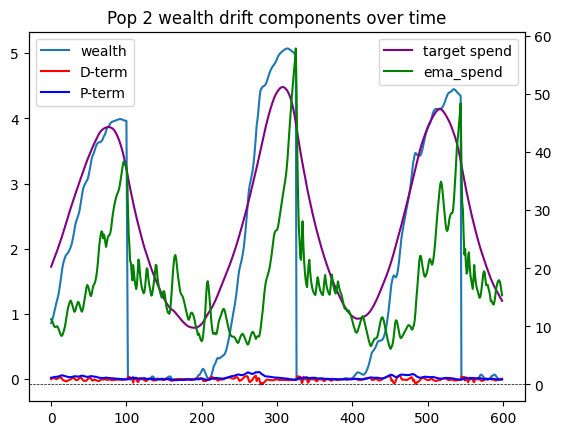

In [42]:
import matplotlib.pyplot as plt

result = run_simulation(SCENARIO, TICKS, output_dir=str(OUTPUT),
                            human_save_every=1, build=True)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit(1)

wealth = []
balance = []
ema_spend = []
d_terms = []
p_terms = []
target_spend = []

# filter result.stdout by lines starting with "Pop " to see wealth drift logs (if any).
tick = 0
print("tick 0")
for line in result.stdout.splitlines():
    if line.startswith("Pop "):
        if line.startswith("Pop 0"):
            tick += 1
            wealth.append(float(line.split("drift: ")[1].split(" -> ")[0]))
            balance.append(float(line.split("balance=")[1].split(",")[0]))
            d_terms.append(float(line.split("d_term=")[1].split(",")[0]))
            p_terms.append(float(line.split("p_term=")[1].split(",")[0]))
            target_spend.append(float(line.split("target_spend=")[1].split(",")[0]))
            ema_spend.append(float(line.split("ema_spend=")[1].split(")")[0]))

plt.plot(wealth[100:700], label="wealth")
#plt.plot(balance[100:700], label="balance", color="orange")
plt.plot(d_terms[100:700], label="D-term", color="red")
plt.plot(p_terms[100:700], label="P-term", color="blue")
plt.legend(loc="upper left")
plt.twinx()
plt.plot(target_spend[100:700], label="target spend", color="purple")
plt.plot(ema_spend[100:700], label="ema_spend", color="green")
plt.legend(loc="upper right")
plt.title("Pop 2 wealth drift components over time")
plt.axhline(0, color="k", lw=0.5, ls="--")
plt.xlabel("tick")


In [5]:
line

'Pop 0 category staple_food: wealth=0.00, base_qty=10.00, scale=1.00, final_qty=10.00Pop 0 wealth drift: 0.000 -> 0.000 (relative_spend_error=-0.079, p_term=-0.039, d_term=-0.786, balance=56.00, target_balance=5.60, ema_spend=10.00)'

In [1]:
import matplotlib.pyplot as plt

result = run_simulation(SCENARIO, TICKS, output_dir=str(OUTPUT),
                            human_save_every=1, build=True)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit(1)

# filter result.stdout by lines starting with "Pop " to see wealth drift logs (if any).
tick = 0
print("tick 0")
for line in result.stdout.splitlines():
    if line.startswith("Building 3"):
        print(line)
        if line.startswith("Building 3 "):
            tick += 1
            print(f"tick {tick}")
        


NameError: name 'run_simulation' is not defined

Suite: 25 scenarios, 1000 ticks each, save every 1
Building binary…
  multi_region: 100 checkpoints cached, skipping
  lr_00: 100 checkpoints cached, skipping
  lr_01: 100 checkpoints cached, skipping
  lr_02: 100 checkpoints cached, skipping
  lr_03: 100 checkpoints cached, skipping
  lr_04: 100 checkpoints cached, skipping
  lr_05: 100 checkpoints cached, skipping
  lr_06: 100 checkpoints cached, skipping
  lr_07: 100 checkpoints cached, skipping
  lr_08: 100 checkpoints cached, skipping
  lr_09: 100 checkpoints cached, skipping
  lr_10: 100 checkpoints cached, skipping
  lr_11: 100 checkpoints cached, skipping
  lr_12: 100 checkpoints cached, skipping
  lr_13: 100 checkpoints cached, skipping
  lr_14: 100 checkpoints cached, skipping
  lr_15: 100 checkpoints cached, skipping
  lr_16: 100 checkpoints cached, skipping
  lr_17: 100 checkpoints cached, skipping
  lr_18: 100 checkpoints cached, skipping
  lr_19: 100 checkpoints cached, skipping
  lr_20: 100 checkpoints cached, skipping
 

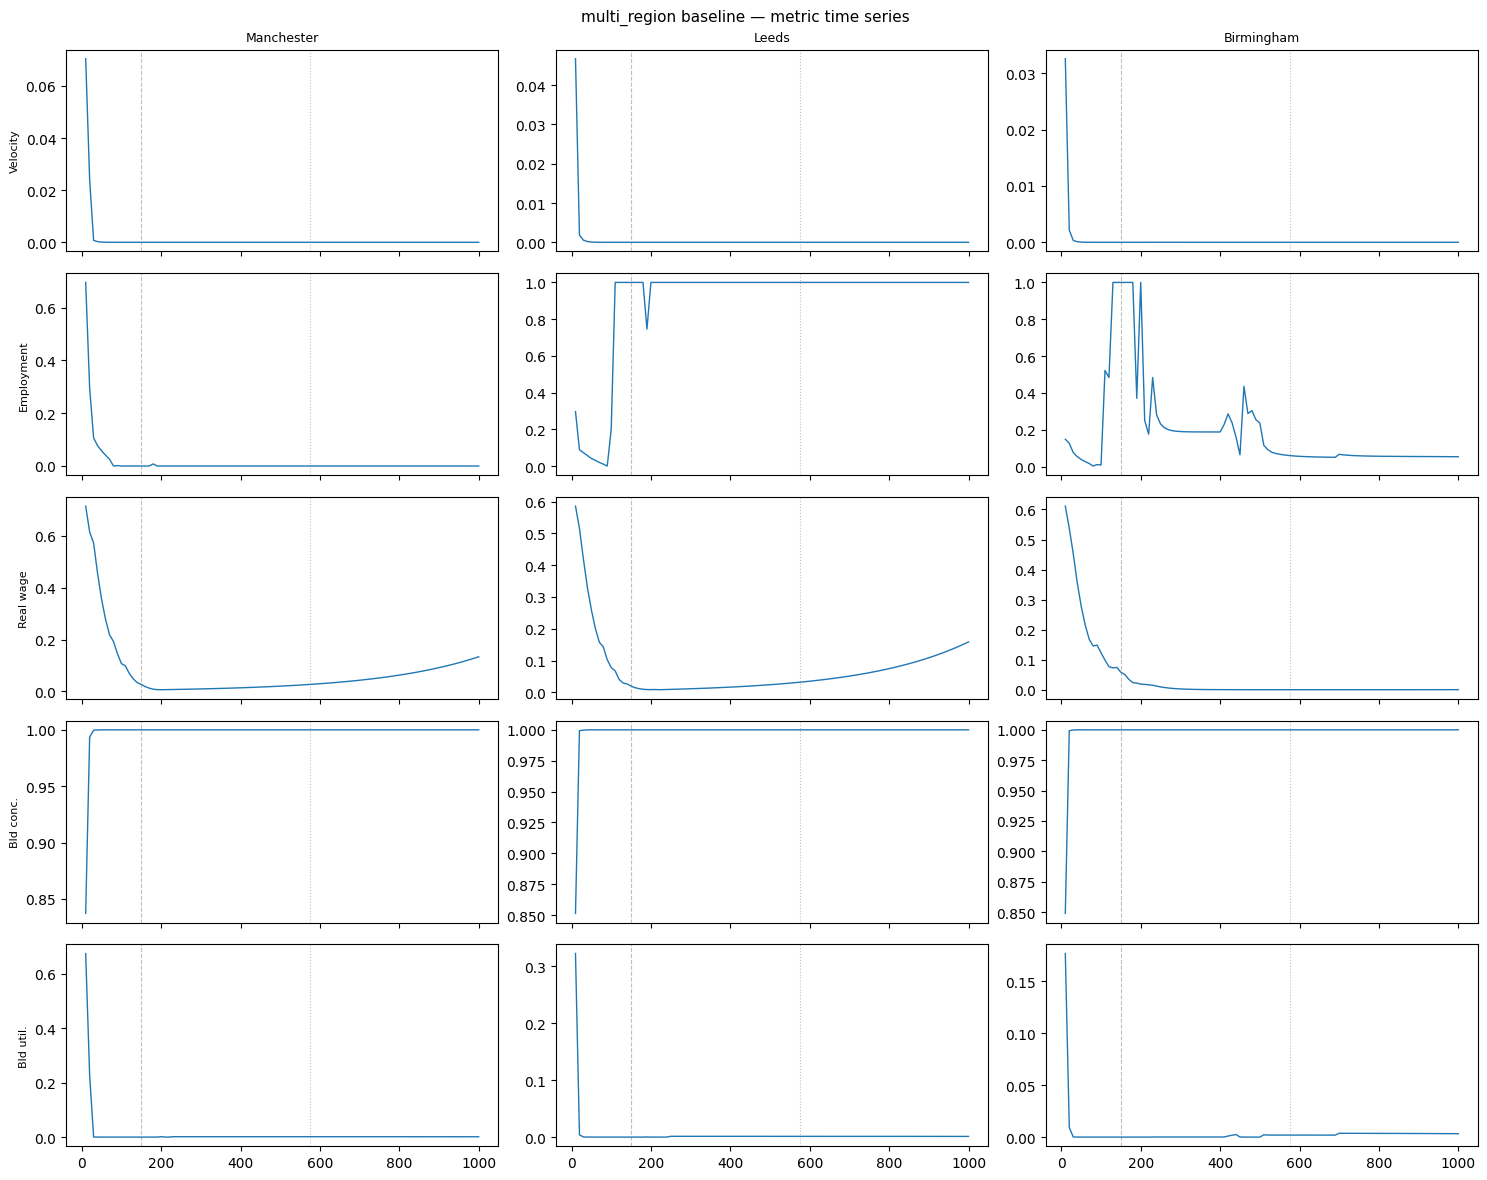

In [4]:
"""
Labour stability test suite runner and analyser.

Runs all 24 lr_XX scenarios plus the multi_region baseline for TICKS ticks,
saves checkpoints every SAVE_EVERY ticks, then computes per-region stability
metrics and issues.

PLOTS = False  (set True in .ipynb to see charts)
"""

import copy, csv, subprocess, sys
from pathlib import Path
from dataclasses import dataclass, field

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "Cargo.toml").exists())
sys.path.insert(0, str(_root / "tools"))

import numpy as np
import pandas as pd

from scenario import SCENARIOS_DIR, REPO_ROOT, run_simulation, load_scenario
from readers import load_scenario_results, ScenarioResults

# ── Settings ──────────────────────────────────────────────────────────────────

PLOTS       = True
TICKS       = 1000
SAVE_EVERY  = 1           # 1000 checkpoints per scenario
TRANSIENT   = 150         # ticks to discard as startup noise
ANALYSIS_END = TICKS
ANALYSIS_MID = TRANSIENT + (ANALYSIS_END - TRANSIENT) // 2   # ~575

# Output dirs
OUT_BASE    = REPO_ROOT / "tmp" / "stability_suite"
MANIFEST    = SCENARIOS_DIR / "lr_manifest.csv"

# Thresholds for issue detection
T_DEAD_VELOCITY    = 0.003   # velocity below this for >80% of window → DEAD
T_DEAD_EMPLOY      = 0.05    # employment below this for >80% of window → DEAD
T_UNSTABLE_CV      = 0.12    # rolling-10 CV above this sustained → UNSTABLE
T_SWING_DAMP       = 0.72    # std ratio (2nd/1st half) above this → SWINGING
T_DRAIN_FRAC       = 0.82    # buildings hold >82% of regional GBP → DRAIN
T_DRAIN_SLOPE      = 0.0     # positive slope in 2nd half confirms drain trending up
T_DESTITUTION      = 0.8     # employed pop GBP < this × flour_cost × 1 week → DESTITUTION
T_DEAD_BLD_UTIL    = 0.05    # chosen/recipe < 5% for >60% of window → dead building
T_DEAD_BLD_FRAC    = 0.60

# ── Scenario list ─────────────────────────────────────────────────────────────

def scenario_list():
    names = ["multi_region"]
    if MANIFEST.exists():
        with open(MANIFEST) as f:
            rows = list(csv.DictReader(f))
        names += [r["name"] for r in rows]
        labels = {"multi_region": "baseline"} | {r["name"]: r["label"] for r in rows}
    else:
        labels = {"multi_region": "baseline"}
    return names, labels

# ── Run simulations (cached) ──────────────────────────────────────────────────

def run_all(names):
    OUT_BASE.mkdir(parents=True, exist_ok=True)
    print("Building binary…")
    subprocess.run(["cargo", "build"], cwd=str(REPO_ROOT),
                   capture_output=True, check=True)

    for name in names:
        out = OUT_BASE / name
        existing = list(out.glob("tick_*.ron"))
        if existing:
            print(f"  {name}: {len(existing)} checkpoints cached, skipping")
            continue
        out.mkdir(parents=True, exist_ok=True)
        print(f"  {name}: running {TICKS} ticks…", end=" ", flush=True)
        r = run_simulation(name, ticks=TICKS, output_dir=str(out),
                           human_save_every=SAVE_EVERY, build=False)
        if r.returncode != 0:
            print(f"ERROR\n{r.stderr[-500:]}")
        else:
            print("done")

# ── Load results ──────────────────────────────────────────────────────────────

def load_all(names):
    results = {}
    for name in names:
        out = OUT_BASE / name
        if not list(out.glob("tick_*.ron")):
            print(f"  {name}: no checkpoints, skipping")
            continue
        gd = load_scenario(name)
        results[name] = load_scenario_results(str(out), gd)
    return results

# ── Metric helpers ────────────────────────────────────────────────────────────

def _node_for_region(res, region_id):
    return next((n for n, r in res.node_to_region.items() if r == region_id), None)

def _good_id(res, name):
    return next((k for k, v in res.good_name.items() if v == name), None)

def _currency_id(res, node_id):
    return res.node_currency.get(node_id)

def rolling_cv(series, window=10):
    """Mean coefficient of variation over a rolling window."""
    s = series.dropna()
    if len(s) < window * 2:
        return np.nan
    rm = s.rolling(window).mean().abs()
    rs = s.rolling(window).std()
    cv = (rs / rm.replace(0, np.nan)).dropna()
    return float(cv.mean())

def damping_ratio(series, mid):
    """std(second half) / std(first half). <1 means settling."""
    s = series.dropna()
    first  = s[s.index < mid]
    second = s[s.index >= mid]
    s1 = float(first.std())  if len(first)  > 5 else np.nan
    s2 = float(second.std()) if len(second) > 5 else np.nan
    if s1 is np.nan or s1 < 1e-12:
        return 0.0   # already settled
    if s2 is np.nan:
        return np.nan
    return s2 / s1

def analysis_slice(series):
    return series[(series.index >= TRANSIENT) & (series.index <= ANALYSIS_END)]

def frac_below(series, thresh):
    s = analysis_slice(series).dropna()
    if len(s) == 0: return np.nan
    return float((s < thresh).mean())

def linear_slope(series):
    s = series.dropna()
    if len(s) < 3: return 0.0
    x = np.arange(len(s), dtype=float)
    return float(np.polyfit(x, s.values, 1)[0])

# ── Per-region metrics ────────────────────────────────────────────────────────

def compute_metrics(res: ScenarioResults, region_id: int) -> dict:
    node = _node_for_region(res, region_id)
    if node is None:
        return {}

    cid  = _currency_id(res, node)
    labour_gid = _good_id(res, "labour")
    flour_gid  = _good_id(res, "flour")
    wheat_gid  = _good_id(res, "wheat")
    nc_goods = [g for g in res.good_name if g != cid]

    # ── Prices at this node ───────────────────────────────────────────────────
    node_prices = res.prices[res.prices["node_id"] == node].copy()
    node_prices["cleared"] = node_prices[["supply", "demand"]].min(axis=1)
    node_prices["txn_value"] = node_prices["cleared"] * node_prices["price"]

    nc_prices = node_prices[node_prices["good_id"].isin(nc_goods)]
    txn_by_tick = nc_prices.groupby("tick")["txn_value"].sum()
    trade_vol   = nc_prices.groupby("tick")["cleared"].sum()

    # ── Currency holdings ─────────────────────────────────────────────────────
    region_blds = res.buildings[res.buildings["region_id"] == region_id]["building_id"].unique()
    region_pops = res.pops[res.pops["region_id"] == region_id]["pop_id"].unique()

    if cid is not None:
        inv = res.inventories[res.inventories["good_id"] == cid].copy()
        inv_bld = inv[(inv["entity_type"] == "building") &
                      (inv["entity_id"].isin(region_blds))]
        inv_pop = inv[(inv["entity_type"] == "pop") &
                      (inv["entity_id"].isin(region_pops))]
        bld_gbp = inv_bld.groupby("tick")["qty"].sum()
        pop_gbp = inv_pop.groupby("tick")["qty"].sum()
        total_gbp = bld_gbp.add(pop_gbp, fill_value=0)
    else:
        total_gbp = pd.Series(dtype=float)
        bld_gbp   = pd.Series(dtype=float)
        pop_gbp   = pd.Series(dtype=float)

    # Velocity = transaction value / total GBP
    velocity = txn_by_tick / total_gbp.replace(0, np.nan)

    # GBP concentration: buildings' share
    concentration = bld_gbp / total_gbp.replace(0, np.nan)

    # ── Employment ────────────────────────────────────────────────────────────
    region_pop_df = res.pops[res.pops["region_id"] == region_id].copy()
    emp_df   = region_pop_df[region_pop_df["is_employed"] == True]
    unemp_df = region_pop_df[region_pop_df["is_employed"] == False]
    emp_size   = emp_df.groupby("tick")["size"].sum()
    total_size = region_pop_df.groupby("tick")["size"].sum()
    employment = emp_size / total_size.replace(0, np.nan)

    # ── Real wage (labour price / flour price) ────────────────────────────────
    labour_p = (node_prices[node_prices["good_id"] == labour_gid]
                .groupby("tick")["price"].mean() if labour_gid is not None
                else pd.Series(dtype=float))
    flour_p  = (node_prices[node_prices["good_id"] == flour_gid]
                .groupby("tick")["price"].mean() if flour_gid is not None
                else pd.Series(dtype=float))
    real_wage = labour_p / flour_p.replace(0, np.nan)

    # ── Building utilisation (non-channel buildings in this region) ───────────
    region_bld_df = res.buildings[
        (res.buildings["region_id"] == region_id) &
        (res.buildings["channel_id"] == -1)
    ].copy()
    region_bld_df["util"] = (region_bld_df["chosen_size"] /
                              region_bld_df["recipe_size"].replace(0, np.nan)).clip(0, 1)
    bld_util = region_bld_df.groupby("tick")["util"].mean()

    # ── Employed pop real income (GBP per employed capita / flour cost) ───────
    emp_pops_inv = (res.inventories[
        (res.inventories["entity_type"] == "pop") &
        (res.inventories["entity_id"].isin(
            emp_df["pop_id"].unique() if "pop_id" in emp_df else []))
    ] if cid is not None else pd.DataFrame())

    if cid is not None and not emp_pops_inv.empty:
        emp_gbp = (emp_pops_inv[emp_pops_inv["good_id"] == cid]
                   .groupby("tick")["qty"].sum())
        emp_total_size = emp_df.groupby("tick")["size"].sum()
        gbp_per_cap = emp_gbp / emp_total_size.replace(0, np.nan)
        real_income = gbp_per_cap / flour_p.replace(0, np.nan)
    else:
        real_income = pd.Series(dtype=float)

    return dict(
        velocity=velocity,
        trade_vol=trade_vol,
        employment=employment,
        real_wage=real_wage,
        concentration=concentration,
        bld_util=bld_util,
        real_income=real_income,
        bld_gbp=bld_gbp,
        pop_gbp=pop_gbp,
        flour_price=flour_p,
        labour_price=labour_p,
        region_bld_df=region_bld_df,
    )

# ── Issue detection ───────────────────────────────────────────────────────────

@dataclass
class RegionResult:
    region_name: str
    issues: list = field(default_factory=list)
    metrics: dict = field(default_factory=dict)

    def passed(self):
        fatal = {"DEAD", "UNSTABLE", "SWINGING", "CURRENCY_DRAIN", "POP_DESTITUTION"}
        return not any(i in fatal for i in self.issues)

def detect_issues(m: dict, res: ScenarioResults) -> list:
    issues = []

    vel = analysis_slice(m["velocity"])
    emp = analysis_slice(m["employment"])
    util = analysis_slice(m["bld_util"])
    conc = analysis_slice(m["concentration"])
    rw   = analysis_slice(m["real_wage"])
    ri   = analysis_slice(m["real_income"])

    # ── DEAD ─────────────────────────────────────────────────────────────────
    if vel.empty or (frac_below(m["velocity"], T_DEAD_VELOCITY) > 0.80):
        issues.append("DEAD")
        return issues   # no point checking further

    if not emp.empty and frac_below(m["employment"], T_DEAD_EMPLOY) > 0.80:
        issues.append("DEAD(employment)")

    # ── UNSTABLE: short-term oscillation ─────────────────────────────────────
    for label, series in [("velocity", m["velocity"]),
                           ("employment", m["employment"]),
                           ("real_wage", m["real_wage"])]:
        s = analysis_slice(series)
        if s.empty: continue
        cv = rolling_cv(s, window=10)
        if cv is not np.nan and cv > T_UNSTABLE_CV:
            issues.append(f"UNSTABLE({label} CV={cv:.2f})")

    # ── SWINGING: not damping ─────────────────────────────────────────────────
    for label, series in [("velocity", m["velocity"]),
                           ("real_wage", m["real_wage"])]:
        s = analysis_slice(series)
        if s.empty: continue
        dr = damping_ratio(s, ANALYSIS_MID)
        if dr is not np.nan and dr > T_SWING_DAMP:
            issues.append(f"SWINGING({label} damp={dr:.2f})")

    # ── CURRENCY_DRAIN ────────────────────────────────────────────────────────
    if not conc.empty:
        second_half = conc[conc.index >= ANALYSIS_MID].dropna()
        mean_conc = float(conc.mean())
        slope = linear_slope(second_half) if len(second_half) > 5 else 0.0
        if mean_conc > T_DRAIN_FRAC and slope > T_DRAIN_SLOPE:
            issues.append(f"CURRENCY_DRAIN({mean_conc:.2f} bld share, slope={slope:.4f})")

    # ── POP_DESTITUTION ───────────────────────────────────────────────────────
    if not ri.empty:
        frac_dest = frac_below(m["real_income"], T_DESTITUTION)
        if frac_dest is not np.nan and frac_dest > 0.50:
            issues.append(f"POP_DESTITUTION(frac={frac_dest:.2f})")

    # ── DEAD_BUILDING (warning) ───────────────────────────────────────────────
    bld_df = m.get("region_bld_df", pd.DataFrame())
    if not bld_df.empty:
        for bid, grp in bld_df.groupby("building_id"):
            a = grp[grp["tick"] >= TRANSIENT]
            if len(a) == 0: continue
            frac_dead = float((a["util"] < T_DEAD_BLD_UTIL).mean())
            if frac_dead > T_DEAD_BLD_FRAC:
                rname = res.recipe_name.get(int(a["recipe_id"].iloc[0]), f"bld{bid}")
                issues.append(f"DEAD_BUILDING({rname})")

    return issues

# ── Summary stats for printing ────────────────────────────────────────────────

def summary_stats(m: dict) -> dict:
    def _mean(series):
        s = analysis_slice(series).dropna()
        return float(s.mean()) if len(s) > 0 else float("nan")
    return {
        "vel_mean":  round(_mean(m["velocity"]),   3),
        "emp_mean":  round(_mean(m["employment"]), 3),
        "rw_mean":   round(_mean(m["real_wage"]),  3),
        "conc_mean": round(_mean(m["concentration"]), 3),
        "util_mean": round(_mean(m["bld_util"]),   3),
    }

# ── Main analysis ─────────────────────────────────────────────────────────────

def analyse_all(all_results: dict, labels: dict):
    scenario_rows = []

    for name, res in all_results.items():
        label = labels.get(name, name)
        regions = sorted(r for r in res.node_to_region.values() if r is not None)
        region_results = []

        for rid in regions:
            rname = res.region_name.get(rid, f"r{rid}")
            m = compute_metrics(res, rid)
            if not m:
                region_results.append(RegionResult(rname, ["NO_DATA"]))
                continue
            issues = detect_issues(m, res)
            rr = RegionResult(rname, issues, summary_stats(m))
            region_results.append(rr)

        passing = sum(1 for rr in region_results if rr.passed())
        total   = len(region_results)
        scenario_rows.append((name, label, passing, total, region_results))

    return scenario_rows

# ── Print report ──────────────────────────────────────────────────────────────

def print_report(rows):
    print("\n" + "=" * 72)
    print("STABILITY SUITE RESULTS")
    print("=" * 72)

    issue_counts = {}
    for name, label, passing, total, region_results in rows:
        score = f"{passing}/{total}"
        status = "✓" if passing == total else "✗"
        print(f"\n{status} {name:20s}  [{score}]  ({label})")
        for rr in region_results:
            flag = "PASS" if rr.passed() else "FAIL"
            issues_str = ", ".join(rr.issues) if rr.issues else "-"
            stats = rr.metrics
            print(f"    {rr.region_name:12s} {flag}  vel={stats.get('vel_mean','?'):.3f}"
                  f"  emp={stats.get('emp_mean','?'):.2f}"
                  f"  rw={stats.get('rw_mean','?'):.2f}"
                  f"  conc={stats.get('conc_mean','?'):.2f}"
                  f"  util={stats.get('util_mean','?'):.2f}")
            if rr.issues:
                print(f"               ISSUES: {issues_str}")
            for i in rr.issues:
                issue_counts[i.split("(")[0]] = issue_counts.get(i.split("(")[0], 0) + 1

    print("\n" + "-" * 72)
    print("SUMMARY")
    all_passing = sum(p == t for _, _, p, t, _ in rows)
    total_scenarios = len(rows)
    region_totals = sum(t for _, _, _, t, _ in rows)
    region_passing = sum(p for _, _, p, _, _ in rows)
    print(f"  Scenarios: {all_passing}/{total_scenarios} all-regions-pass")
    print(f"  Regions:   {region_passing}/{region_totals} passed")
    print(f"  Issue frequency:")
    for issue, count in sorted(issue_counts.items(), key=lambda x: -x[1]):
        print(f"    {issue:30s} {count}")
    print("=" * 72)

# ── Plots ─────────────────────────────────────────────────────────────────────

def make_plots(rows, all_results):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    names   = [r[0] for r in rows]
    passing = [r[2] / max(r[3], 1) for r in rows]
    labels  = [r[1][:30] for r in rows]

    # ── 1. Pass rate bar chart ────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 5))
    colours = ["#2ca02c" if p == 1.0 else "#ff7f0e" if p > 0 else "#d62728"
               for p in passing]
    ax.bar(range(len(names)), passing, color=colours)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Fraction of regions passing")
    ax.set_title("Stability pass rate by scenario")
    ax.axhline(1.0, color="green", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(_root / "tmp" / "stability_pass_rate.png", dpi=120)
    plt.close()

    # ── 2. Heatmap of key metrics across scenarios ────────────────────────────
    metric_names = ["vel_mean", "emp_mean", "rw_mean", "conc_mean", "util_mean"]
    matrix = []
    for name, label, passing, total, region_results in rows:
        row_vals = []
        for mn in metric_names:
            vals = [rr.metrics.get(mn, np.nan) for rr in region_results
                    if not np.isnan(rr.metrics.get(mn, np.nan))]
            row_vals.append(np.nanmean(vals) if vals else np.nan)
        matrix.append(row_vals)
    matrix = np.array(matrix, dtype=float)

    fig, ax = plt.subplots(figsize=(9, max(6, len(names) * 0.3)))
    im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn")
    ax.set_xticks(range(len(metric_names)))
    ax.set_xticklabels(["velocity", "employment", "real wage",
                         "bld conc", "bld util"], fontsize=9)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_title("Mean metric values (analysis window, all regions avg)")
    plt.tight_layout()
    plt.savefig(_root / "tmp" / "stability_heatmap.png", dpi=120)
    plt.close()

    # ── 3. Time series for multi_region baseline ──────────────────────────────
    if "multi_region" in all_results:
        res = all_results["multi_region"]
        regions = sorted(r for r in res.node_to_region.values() if r is not None)
        fig, axes = plt.subplots(5, len(regions), figsize=(5 * len(regions), 12),
                                  sharex=True)
        if len(regions) == 1:
            axes = [[a] for a in axes]

        for col, rid in enumerate(regions):
            rname = res.region_name.get(rid, f"r{rid}")
            m = compute_metrics(res, rid)
            if not m: continue

            for row, (label, key) in enumerate([
                ("Velocity", "velocity"),
                ("Employment", "employment"),
                ("Real wage", "real_wage"),
                ("Bld conc.", "concentration"),
                ("Bld util.", "bld_util"),
            ]):
                ax = axes[row][col]
                s = m[key].dropna()
                ax.plot(s.index, s.values, lw=1)
                ax.axvline(TRANSIENT, color="grey", linestyle="--", alpha=0.5, lw=0.8)
                ax.axvline(ANALYSIS_MID, color="grey", linestyle=":", alpha=0.5, lw=0.8)
                if col == 0:
                    ax.set_ylabel(label, fontsize=8)
                if row == 0:
                    ax.set_title(rname, fontsize=9)

        fig.suptitle("multi_region baseline — metric time series", fontsize=11)
        plt.tight_layout()
        plt.show()


# ── Entry point ───────────────────────────────────────────────────────────────

if __name__ == "__main__":
    names, labels = scenario_list()
    print(f"Suite: {len(names)} scenarios, {TICKS} ticks each, save every {SAVE_EVERY}")

    run_all(names)

    print("\nLoading results…")
    all_results = load_all(names)
    print(f"  Loaded {len(all_results)} scenarios")

    print("\nAnalysing…")
    rows = analyse_all(all_results, labels)

    print_report(rows)

    if PLOTS:
        make_plots(rows, all_results)
